In [2]:
# CELL 1: Global Setup
# ═══════════════════════════════════════════════════════════════════════════════
# All constants, colors, and helpers needed by subsequent cells.
# Canonical: 4 categories (face, house, object, word).
# PPA/TOS split available for future supplemental work (commented out).
# ═══════════════════════════════════════════════════════════════════════════════

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Patch, Ellipse
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.linalg import orthogonal_procrustes
from scipy import stats as sp_stats

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE    = Path(processed_dir)
SEL_DIR = BASE / 'group_results' / 'selectivity'
LIU_DIR = BASE / 'group_results' / 'liu_distinctiveness'
GEO_DIR = BASE / 'group_results' / 'geometry'
FIG_DIR = BASE / 'group_results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Cope set ──────────────────────────────────────────────────────────────────
COPE_SET = 'differential'

# ── Group colors ──────────────────────────────────────────────────────────────
CTRL_L = '#a0a0a0'
CTRL_R = '#505050'
OTC_L  = '#7398af'
OTC_R  = '#ee7183'
NONOT  = '#FF9800'

# ── Categories (canonical: 4) ─────────────────────────────────────────────────
CATEGORIES = ['face', 'house', 'object', 'word']
BILATERAL  = ['house', 'object']
UNILATERAL = ['face', 'word']

CAT_COLORS = {
    'face':   '#cc0066',   # magenta
    'word':   '#ff8800',   # orange
    'house':  '#009900',   # green
    'object': '#0077cc',   # blue
}

CAT_MARKERS = {
    'face':   'o',
    'word':   's',
    'house':  '^',
    'object': 'D',
}

# ── Reorganized category per resection side ───────────────────────────────────
REORG = {'left': 'word', 'right': 'face'}

# ── Preferred control hemisphere for Crawford comparisons ─────────────────────
PREFERRED_CTRL_HEMI = {
    'face':   'right',
    'word':   'left',
    'house':  'left',
    'object': 'left',
}

# ── Preferred hemisphere for neural heatmap projection ────────────────────────
PREF_HEMI_NEURAL = {
    'face':   'right',
    'word':   'left',
    'house':  'right',
    'object': 'left',
}

# ── Plot defaults ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

RNG = np.random.default_rng(42)

# ── Shared helpers ────────────────────────────────────────────────────────────

def short_name(code):
    """Compact subject label for plot annotations."""
    return (code.replace('OTC', '').replace('nonOTC', 'n')
                .replace('control', 'c').replace('sub-', ''))


def confidence_ellipse(x, y, ax, n_std=1.0, **kwargs):
    """1-SD covariance ellipse for scatter (x, y). Needs >= 3 points."""
    if len(x) < 3:
        return
    cov     = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx, ry  = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2, **kwargs)
    sx      = np.sqrt(cov[0, 0]) * n_std
    sy      = np.sqrt(cov[1, 1]) * n_std
    t = (transforms.Affine2D()
         .rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(t + ax.transData)
    ax.add_patch(ellipse)


# ── PPA/TOS extension (peak coords + supplemental) ───────────────────────────
CATEGORIES_PEAK = ['face', 'house_PPA', 'house_TOS', 'object', 'word']
CAT_COLORS_PEAK = {
    **CAT_COLORS,
    'house_PPA': '#005500',   # dark green
    'house_TOS': '#66cc00',   # yellow-green
}
CAT_MARKERS_PEAK = {
    **CAT_MARKERS,
    'house_PPA': '^',
    'house_TOS': 'v',
}
PREFERRED_CTRL_HEMI_PEAK = {
    **PREFERRED_CTRL_HEMI,
    'house_PPA': 'left',
    'house_TOS': 'left',
}

print(f'Setup complete. COPE_SET={COPE_SET}')
print(f'CATEGORIES: {CATEGORIES}')

Setup complete. COPE_SET=differential
CATEGORIES: ['face', 'house', 'object', 'word']


In [3]:
# CELL 2: Crawford Helpers + Shared Data Loaders
# ═══════════════════════════════════════════════════════════════════════════════

def crawford_t(patient_val, ctrl_vals):
    """Crawford & Howell (1998) modified t-test: single case vs controls.
    Returns (t_stat, p_val, n_controls)."""
    ctrl_vals = np.asarray(ctrl_vals)
    ctrl_vals = ctrl_vals[np.isfinite(ctrl_vals)]
    n = len(ctrl_vals)
    if n < 3:
        return np.nan, np.nan, n
    m, s = ctrl_vals.mean(), ctrl_vals.std(ddof=1)
    if s == 0:
        return np.nan, np.nan, n
    t = (patient_val - m) / (s * np.sqrt((n + 1) / n))
    p = 2 * sp_stats.t.sf(abs(t), df=n - 1)
    return t, p, n


def bh_fdr(pvals, alpha=0.05):
    """Benjamini-Hochberg FDR correction. Returns boolean rejected array."""
    pvals = np.asarray(pvals, dtype=float)
    n     = len(pvals)
    if n == 0:
        return np.array([], dtype=bool)
    order    = np.argsort(pvals)
    ranked   = np.empty(n)
    ranked[order] = np.arange(1, n + 1)
    threshold = (ranked / n) * alpha
    below = pvals <= threshold
    if not below.any():
        return np.zeros(n, dtype=bool)
    cutoff = pvals[order[np.where(below)[0].max()]]
    return pvals <= cutoff


def load_liu_first_session(cope_set=COPE_SET):
    """Load liu_distinctiveness CSV; return (ctrl, otc) first-session DataFrames."""
    liu_file = LIU_DIR / f'liu_distinctiveness_{cope_set}.csv'
    if not liu_file.exists():
        print(f'  SKIP: {liu_file} not found')
        return None, None
    df    = pd.read_csv(liu_file)
    first = (df.groupby('subject_id')['session'].min()
               .reset_index().rename(columns={'session': 'fs'}))
    df    = df.merge(first, on='subject_id')
    df    = df[df['session'] == df['fs']]
    ctrl  = df[df['status'] == 'control'].copy()
    otc   = df[(df['group'] == 'OTC') & (df['hemi_label'] == 'intact')].copy()
    return ctrl, otc


def compute_crawford_rows(ctrl, otc):
    """Crawford t/p for every patient x category.
    Returns DataFrame: subject, surgery_side, category, t, p, sig (BH-FDR)."""
    rows = []
    for cat in CATEGORIES:
        ref_hemi  = PREFERRED_CTRL_HEMI[cat]
        ctrl_vals = ctrl[(ctrl['category'] == cat) &
                         (ctrl['hemi_label'] == ref_hemi)]['liu_distinctiveness'].values
        for _, row in otc[otc['category'] == cat].iterrows():
            t, p, _ = crawford_t(row['liu_distinctiveness'], ctrl_vals)
            rows.append({'subject': row['subject'],
                         'surgery_side': row['surgery_side'],
                         'category': cat, 't': t, 'p': p})
    cdf   = pd.DataFrame(rows)
    valid = cdf['p'].notna()
    cdf['sig'] = False
    if valid.sum() > 0:
        cdf.loc[valid, 'sig'] = bh_fdr(cdf.loc[valid, 'p'].values)
    return cdf


print('Crawford helpers and data loaders ready.')

Crawford helpers and data loaders ready.


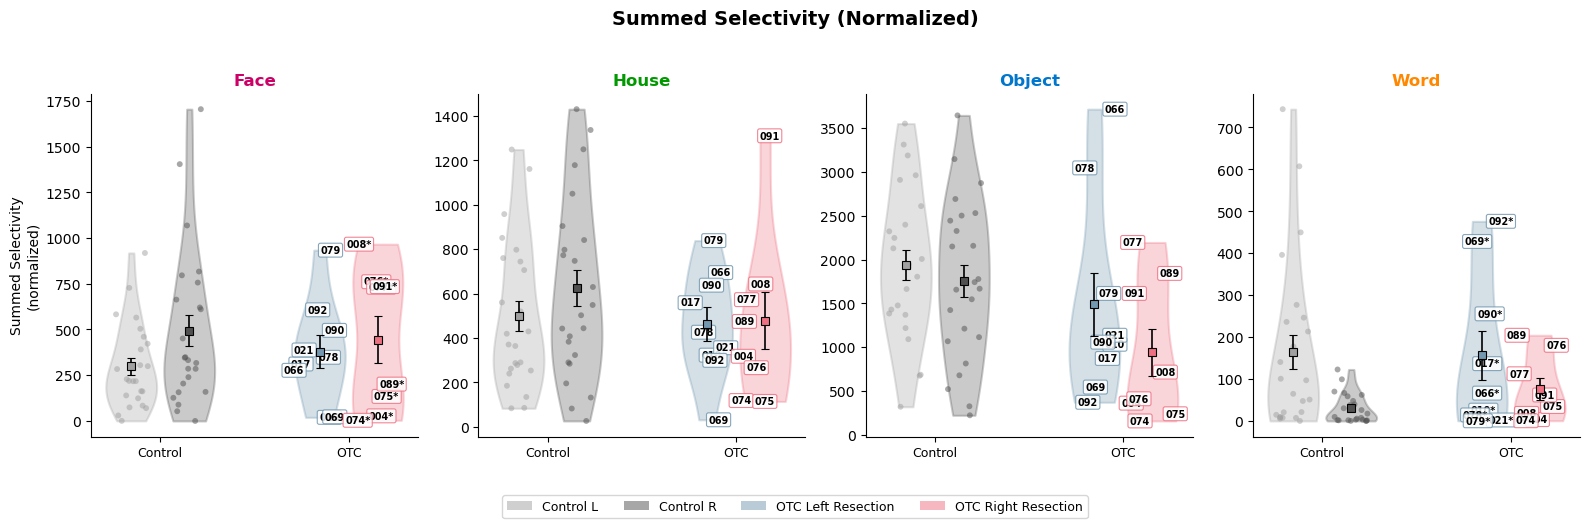

  Saved: fig_selectivity_sum_selec_norm.png


In [4]:
#  CELL 3: Selectivity — Sum Selectivity Norm (Ayzenberg)
# ═══════════════════════════════════════════════════════════════════════════════

def fig_selectivity(metric='sum_selec_norm'):
    """Violin + jitter: selectivity per category,
    Controls L/R vs OTC-left/right, patients labeled."""
    sel_file = SEL_DIR / 'selectivity_summary.csv'
    if not sel_file.exists():
        print(f'  SKIP: {sel_file} not found')
        return

    df = pd.read_csv(sel_file)
    df['ses_int'] = df['ses'].astype(int)
    first = (df.groupby('sub')['ses_int'].min()
               .reset_index().rename(columns={'ses_int': 'fs'}))
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')

    n_cats = len(CATEGORIES)
    fig, axes = plt.subplots(1, n_cats, figsize=(4 * n_cats, 5), sharey=False)

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        vd, vp, vc = [], [], []

        cl = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'left')][metric].values
        cr = ctrl[(ctrl['category'] == cat) & (ctrl['hemi'] == 'right')][metric].values

        for vals, pos, color in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(color)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=color, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        for side, pos, color in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd   = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd[metric].values
            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(color)
            for _, row in sd.iterrows():
                jit  = RNG.uniform(-0.18, 0.18)
                lbl  = short_name(row['sub'])
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f'{lbl}{star}', (pos + jit, row[metric]),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=color, alpha=0.85, linewidth=0.8),
                            zorder=4)
            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals),
                            yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                            color='black', marker='s', markersize=6,
                            markerfacecolor=color, markeredgecolor='black',
                            markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i]); body.set_alpha(0.3)
                body.set_edgecolor(vc[i]); body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold',
                     color=CAT_COLORS[cat])
        if col_idx == 0:
            label_map = {'sum_selec_norm': 'Summed Selectivity\n(normalized)',
                         'mean_act': 'Mean Activation (z)'}
            ax.set_ylabel(label_map.get(metric, metric))

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    title_map = {'sum_selec_norm': 'Summed Selectivity (Normalized)',
                 'mean_act': 'Mean Activation'}
    plt.suptitle(title_map.get(metric, metric), fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_selectivity_{metric}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_selectivity_{metric}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_selectivity('sum_selec_norm')

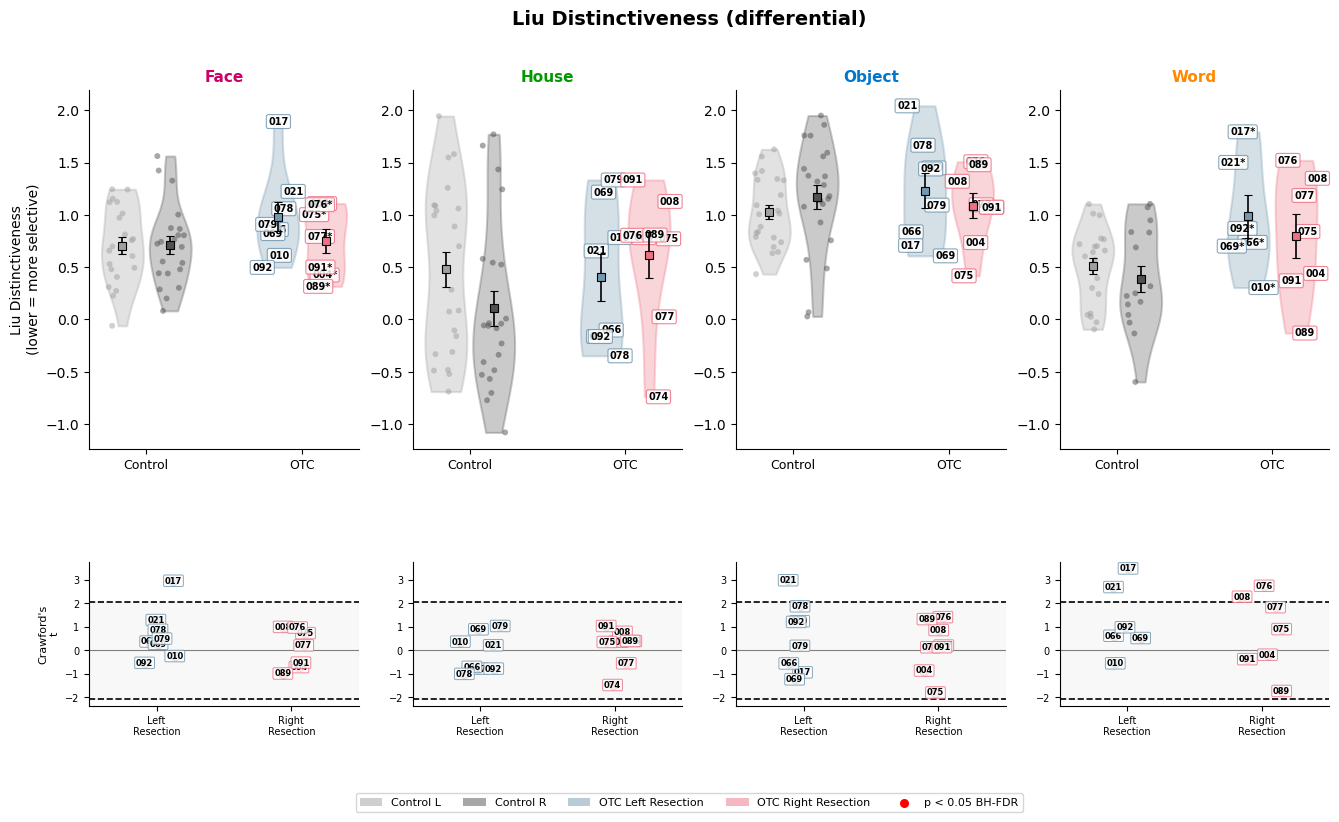

  Saved: fig_liu_differential.png


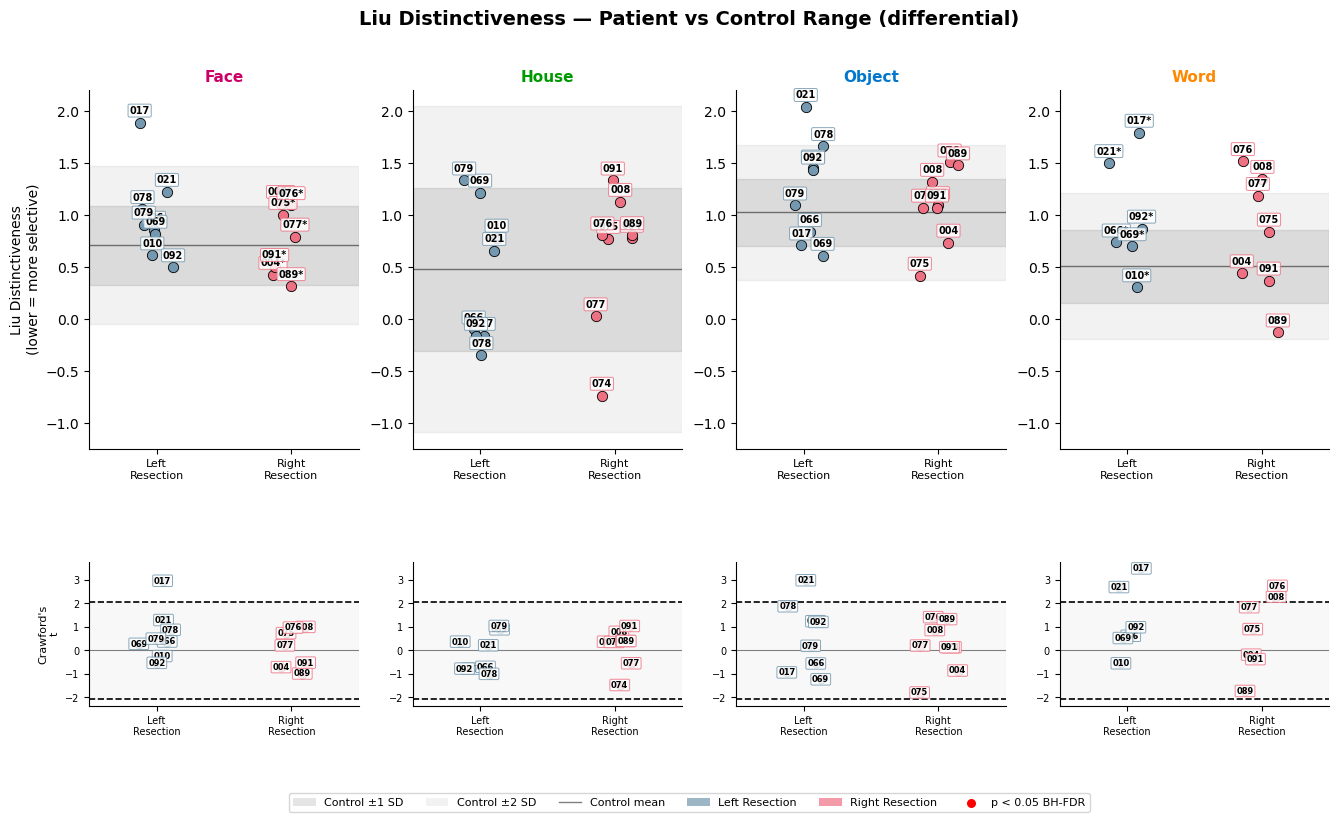

  Saved: fig_liu_range_differential.png


In [5]:
# CELL 4: Liu Distinctiveness — violin+jitter (4-panel) and Liu-style (1-axis)
# ═══════════════════════════════════════════════════════════════════════════════

def fig_liu_distinctiveness(cope_set=COPE_SET):
    """One panel per category: violin + jitter for controls, labeled badges
    for patients, Crawford t-score strip below."""
    ctrl, otc = load_liu_first_session(cope_set)
    if ctrl is None:
        return
    cdf    = compute_crawford_rows(ctrl, otc)
    n_ctrl = ctrl['subject_id'].nunique()
    t_crit = sp_stats.t.ppf(0.975, df=n_ctrl - 1)

    n_cats = len(CATEGORIES)
    fig    = plt.figure(figsize=(4 * n_cats, 8))
    gs     = fig.add_gridspec(2, n_cats, height_ratios=[3, 1.2], hspace=0.45)

    ax_top0, ax_bot0 = None, None
    for col_idx, cat in enumerate(CATEGORIES):
        ax  = fig.add_subplot(gs[0, col_idx], sharey=ax_top0)
        axc = fig.add_subplot(gs[1, col_idx], sharey=ax_bot0)
        if col_idx == 0:
            ax_top0, ax_bot0 = ax, axc
        color = CAT_COLORS[cat]

        # ── Top: violin + jitter ──────────────────────────────────────────────
        vd, vp, vc = [], [], []
        cl = ctrl[(ctrl['category'] == cat) &
                  (ctrl['hemi_label'] == 'left')]['liu_distinctiveness'].values
        cr = ctrl[(ctrl['category'] == cat) &
                  (ctrl['hemi_label'] == 'right')]['liu_distinctiveness'].values

        for vals, pos, c in [(cl, 0.0, CTRL_L), (cr, 0.4, CTRL_R)]:
            if len(vals) < 2:
                continue
            vd.append(vals); vp.append(pos); vc.append(c)
            jit = RNG.uniform(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), pos) + jit, vals,
                       color=c, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(vals), yerr=np.std(vals) / np.sqrt(len(vals)),
                        color='black', marker='s', markersize=6,
                        markerfacecolor=c, markeredgecolor='black',
                        markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        for side, pos, c in [('left', 1.3, OTC_L), ('right', 1.7, OTC_R)]:
            sd   = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            vals = sd['liu_distinctiveness'].values
            if len(vals) >= 2:
                vd.append(vals); vp.append(pos); vc.append(c)
            for _, row in sd.iterrows():
                jit  = RNG.uniform(-0.18, 0.18)
                star = '*' if REORG.get(side) == cat else ''
                ax.annotate(f"{short_name(row['subject'])}{star}",
                            (pos + jit, row['liu_distinctiveness']),
                            fontsize=7, fontweight='bold', ha='center', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                                      edgecolor=c, alpha=0.85, linewidth=0.8),
                            zorder=4)
            if len(vals) > 0:
                ax.errorbar(pos, np.mean(vals),
                            yerr=np.std(vals) / np.sqrt(max(len(vals), 1)),
                            color='black', marker='s', markersize=6,
                            markerfacecolor=c, markeredgecolor='black',
                            markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.35)
            for body, vc_i in zip(vplot['bodies'], vc):
                body.set_facecolor(vc_i); body.set_alpha(0.3)
                body.set_edgecolor(vc_i); body.set_linewidth(1.5)

        ax.set_xticks([0.2, 1.5])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=11, fontweight='bold', color=color)
        if col_idx == 0:
            ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')

        # ── Bottom: Crawford t-scores ─────────────────────────────────────────
        cat_cdf = cdf[cdf['category'] == cat]
        axc.axhline(0,        color='gray',  linewidth=0.8)
        axc.axhline( t_crit,  color='black', linewidth=1.2, linestyle='--')
        axc.axhline(-t_crit,  color='black', linewidth=1.2, linestyle='--')
        axc.axhspan(-t_crit, t_crit, alpha=0.05, color='gray')

        for _, r in cat_cdf.iterrows():
            if np.isnan(r['t']):
                continue
            x   = {'left': 0.0, 'right': 1.0}[r['surgery_side']] + RNG.uniform(-0.15, 0.15)
            c   = OTC_L if r['surgery_side'] == 'left' else OTC_R
            dot = 'red' if r['sig'] else c
            axc.scatter(x, r['t'], color=dot, s=40, zorder=4,
                        edgecolors='black', linewidth=0.5)
            axc.annotate(short_name(r['subject']), (x, r['t']),
                         fontsize=6, fontweight='bold', ha='center', va='center',
                         bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                                   edgecolor=dot, alpha=0.85, linewidth=0.7),
                         zorder=5)

        axc.set_xlim(-0.5, 1.5)
        axc.set_xticks([0.0, 1.0])
        axc.set_xticklabels(['Left\nResection', 'Right\nResection'], fontsize=7)
        if col_idx == 0:
            axc.set_ylabel("Crawford's\nt", fontsize=8)
        axc.tick_params(axis='y', labelsize=7)

    legend_elements = [
        Patch(facecolor=CTRL_L, alpha=0.5, label='Control L'),
        Patch(facecolor=CTRL_R, alpha=0.5, label='Control R'),
        Patch(facecolor=OTC_L,  alpha=0.5, label='OTC Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.5, label='OTC Right Resection'),
        plt.scatter([], [], color='red', s=30, label='p < 0.05 BH-FDR'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=5,
               fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.03))
    plt.suptitle(f'Liu Distinctiveness ({cope_set})', fontsize=14, fontweight='bold')
    plt.savefig(str(FIG_DIR / f'fig_liu_{cope_set}.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_liu_{cope_set}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_liu_distinctiveness(COPE_SET)


def fig_liu_range(cope_set=COPE_SET):
    """Patient dots against control mean +/- 1-2 SD bands, one panel per category,
    with Crawford t-score strip below."""
    ctrl, otc = load_liu_first_session(cope_set)
    if ctrl is None:
        return
    cdf    = compute_crawford_rows(ctrl, otc)
    n_ctrl = ctrl['subject_id'].nunique()
    t_crit = sp_stats.t.ppf(0.975, df=n_ctrl - 1)

    n_cats = len(CATEGORIES)
    fig    = plt.figure(figsize=(4 * n_cats, 8))
    gs     = fig.add_gridspec(2, n_cats, height_ratios=[3, 1.2], hspace=0.45)

    ax_top0, ax_bot0 = None, None
    for col_idx, cat in enumerate(CATEGORIES):
        ax  = fig.add_subplot(gs[0, col_idx], sharey=ax_top0)
        axc = fig.add_subplot(gs[1, col_idx], sharey=ax_bot0)
        if col_idx == 0:
            ax_top0, ax_bot0 = ax, axc
        color = CAT_COLORS[cat]

        # ── Top: control range + patient dots ─────────────────────────────────
        ref_hemi  = PREFERRED_CTRL_HEMI[cat]
        ctrl_vals = ctrl[(ctrl['category'] == cat) &
                         (ctrl['hemi_label'] == ref_hemi)]['liu_distinctiveness'].values

        if len(ctrl_vals) >= 2:
            m, s = np.mean(ctrl_vals), np.std(ctrl_vals)
            ax.axhspan(m - 2*s, m + 2*s, color='gray', alpha=0.10, zorder=0,
                       label='\u00b12 SD' if col_idx == 0 else '')
            ax.axhspan(m - s, m + s, color='gray', alpha=0.20, zorder=1,
                       label='\u00b11 SD' if col_idx == 0 else '')
            ax.axhline(m, color='black', linewidth=1.0, linestyle='-',
                       alpha=0.5, zorder=2)

        # Patient dots — left resection on x=0, right on x=1
        for side, x_pos, c in [('left', 0.0, OTC_L), ('right', 1.0, OTC_R)]:
            sd = otc[(otc['category'] == cat) & (otc['surgery_side'] == side)]
            for _, row in sd.iterrows():
                jit  = RNG.uniform(-0.15, 0.15)
                star = '*' if REORG.get(side) == cat else ''
                ax.scatter(x_pos + jit, row['liu_distinctiveness'],
                           color=c, s=55, zorder=4,
                           edgecolors='black', linewidth=0.6)
                ax.annotate(f"{short_name(row['subject'])}{star}",
                            (x_pos + jit, row['liu_distinctiveness']),
                            fontsize=7, fontweight='bold', ha='center', va='bottom',
                            xytext=(0, 5), textcoords='offset points',
                            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                                      edgecolor=c, alpha=0.85, linewidth=0.7),
                            zorder=5)

        ax.set_xlim(-0.5, 1.5)
        ax.set_xticks([0.0, 1.0])
        ax.set_xticklabels(['Left\nResection', 'Right\nResection'], fontsize=8)
        ax.set_title(cat.title(), fontsize=11, fontweight='bold', color=color)
        if col_idx == 0:
            ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')

        # ── Bottom: Crawford t-scores ─────────────────────────────────────────
        cat_cdf = cdf[cdf['category'] == cat]
        axc.axhline(0,        color='gray',  linewidth=0.8)
        axc.axhline( t_crit,  color='black', linewidth=1.2, linestyle='--')
        axc.axhline(-t_crit,  color='black', linewidth=1.2, linestyle='--')
        axc.axhspan(-t_crit, t_crit, alpha=0.05, color='gray')

        for _, r in cat_cdf.iterrows():
            if np.isnan(r['t']):
                continue
            x   = {'left': 0.0, 'right': 1.0}[r['surgery_side']] + RNG.uniform(-0.15, 0.15)
            c   = OTC_L if r['surgery_side'] == 'left' else OTC_R
            dot = 'red' if r['sig'] else c
            axc.scatter(x, r['t'], color=dot, s=40, zorder=4,
                        edgecolors='black', linewidth=0.5)
            axc.annotate(short_name(r['subject']), (x, r['t']),
                         fontsize=6, fontweight='bold', ha='center', va='center',
                         bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                                   edgecolor=dot, alpha=0.85, linewidth=0.7),
                         zorder=5)

        axc.set_xlim(-0.5, 1.5)
        axc.set_xticks([0.0, 1.0])
        axc.set_xticklabels(['Left\nResection', 'Right\nResection'], fontsize=7)
        if col_idx == 0:
            axc.set_ylabel("Crawford's\nt", fontsize=8)
        axc.tick_params(axis='y', labelsize=7)

    legend_elements = [
        Patch(facecolor='gray', alpha=0.20, label='Control \u00b11 SD'),
        Patch(facecolor='gray', alpha=0.10, label='Control \u00b12 SD'),
        Line2D([0], [0], color='black', linewidth=1.0, alpha=0.5, label='Control mean'),
        Patch(facecolor=OTC_L, alpha=0.7, label='Left Resection'),
        Patch(facecolor=OTC_R, alpha=0.7, label='Right Resection'),
        plt.scatter([], [], color='red', s=30, label='p < 0.05 BH-FDR'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=6,
               fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.03))
    plt.suptitle(f'Liu Distinctiveness \u2014 Patient vs Control Range ({cope_set})',
                 fontsize=14, fontweight='bold')
    plt.savefig(str(FIG_DIR / f'fig_liu_range_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_liu_range_{cope_set}.png')


fig_liu_range(COPE_SET)

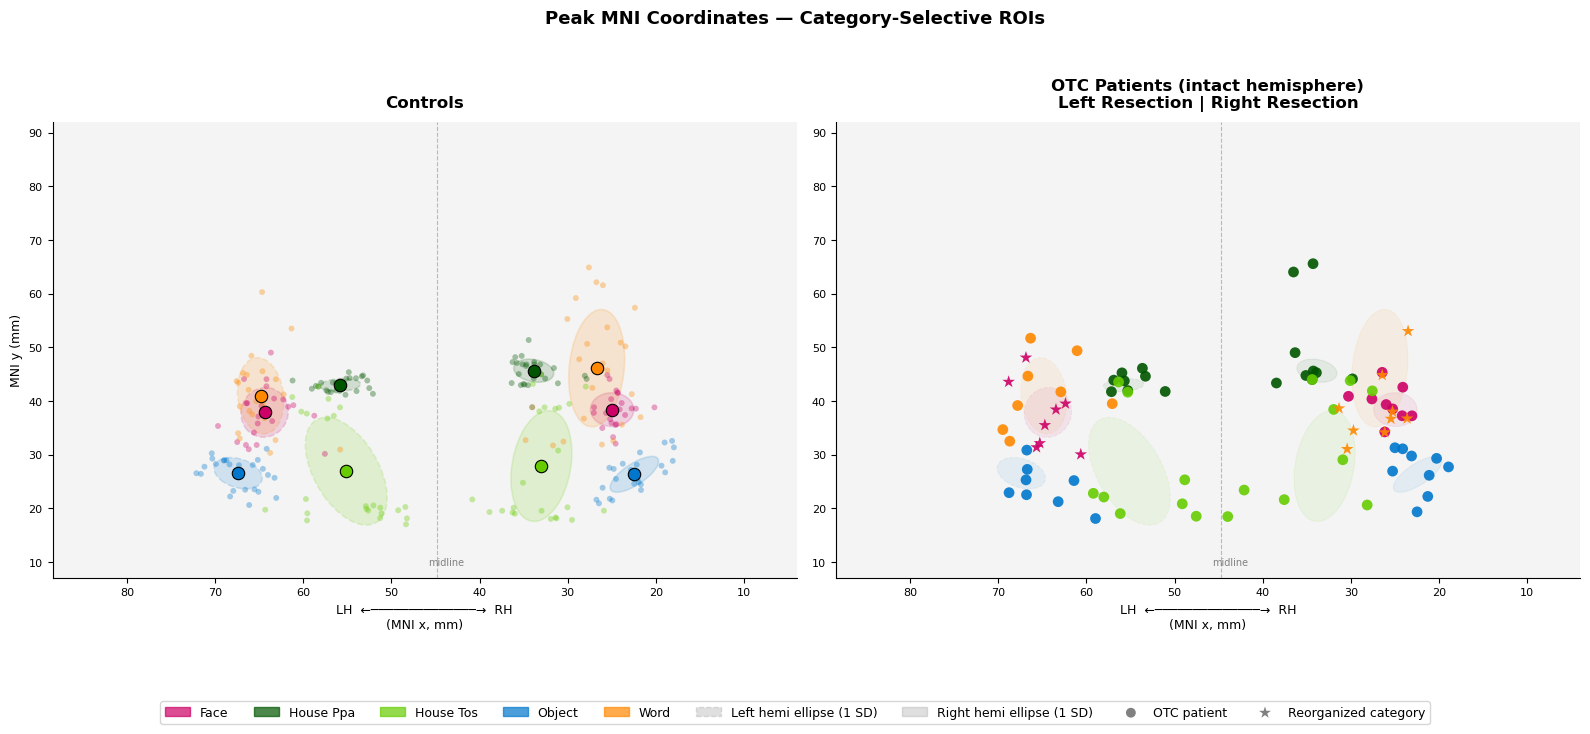

  Saved: fig_peak_coords.png


In [6]:
# CELL 5: Peak MNI Coordinates — dot + star for reorganized category
# ═══════════════════════════════════════════════════════════════════════════════

def fig_peak_coordinates(suffix=''):
    """Liu Fig.2-style 2D MNI scatter (uses PPA/TOS split for house).
    Controls: 1-SD ellipses per hemi + small dots + centroid.
    Patients: circles (star = reorganized category only)."""

    pk_file = BASE / 'group_results' / 'peak_coords' / f'peak_coords{suffix}.csv'
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    cats = CATEGORIES_PEAK

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)
    first = (df.groupby('sub')['ses_int'].min()
               .reset_index().rename(columns={'ses_int': 'fs'}))
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')
    otc = otc[((otc['intact_hemi'] == 'left')  & (otc['hemi'] == 'left')) |
              ((otc['intact_hemi'] == 'right') & (otc['hemi'] == 'right'))]

    lx = ctrl[ctrl['hemi'] == 'left']['peak_x_mni'].mean()
    rx = ctrl[ctrl['hemi'] == 'right']['peak_x_mni'].mean()
    midline_x = (lx + rx) / 2

    pad  = 10
    xlim = (ctrl['peak_x_mni'].min() - pad, ctrl['peak_x_mni'].max() + pad)
    ylim = (ctrl['peak_y_mni'].min() - pad, ctrl['peak_y_mni'].max() + pad)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.patch.set_facecolor('white')

    for ax_idx in range(2):
        ax      = axes[ax_idx]
        is_ctrl = (ax_idx == 0)
        ax.set_facecolor('#f4f4f4')

        for cat in cats:
            color = CAT_COLORS_PEAK[cat]

            # Control ellipses
            for hemi, ls in [('left', '--'), ('right', '-')]:
                hdat = ctrl[(ctrl['category'] == cat) &
                            (ctrl['hemi'] == hemi)].dropna(
                                subset=['peak_x_mni', 'peak_y_mni'])
                x, y  = hdat['peak_x_mni'].values, hdat['peak_y_mni'].values
                alpha = 0.15 if is_ctrl else 0.07
                lw    = 1.2  if is_ctrl else 0.8
                if len(x) >= 3:
                    confidence_ellipse(x, y, ax, n_std=1.0, facecolor=color,
                                       alpha=alpha, edgecolor=color,
                                       linewidth=lw, linestyle=ls, zorder=2)
                if is_ctrl:
                    ax.scatter(x, y, color=color, alpha=0.35, s=18,
                               edgecolors='none', zorder=3)
                    if len(x) >= 2:
                        ax.scatter(np.mean(x), np.mean(y), color=color, s=80,
                                   edgecolors='black', linewidth=0.8,
                                   marker='o', zorder=5)

            # Patient dots — both groups on one panel
            if not is_ctrl:
                for side_data, side in [(otc[otc['surgery_side'] == 'left'], 'left'),
                                        (otc[otc['surgery_side'] == 'right'], 'right')]:
                    pcat = side_data[side_data['category'] == cat].dropna(
                        subset=['peak_x_mni', 'peak_y_mni'])
                    for _, row in pcat.iterrows():
                        is_reorg = (REORG.get(side) == cat)
                        ax.scatter(row['peak_x_mni'], row['peak_y_mni'],
                                   color=color,
                                   s=90 if is_reorg else 60,
                                   marker='*' if is_reorg else 'o',
                                   edgecolors='none',
                                   alpha=0.9, zorder=6)

        ax.axvline(midline_x, color='gray', linewidth=0.8,
                   linestyle='--', alpha=0.5, zorder=1)
        ax.text(midline_x + 1, ylim[0] + 2, 'midline',
                fontsize=7, color='gray', va='bottom')
        ax.set_xlim(xlim)
        ax.invert_xaxis()
        ax.set_ylim(ylim)
        ax.set_xlabel('LH  \u2190\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2192  RH\n(MNI x, mm)', fontsize=9)
        if ax_idx == 0:
            ax.set_ylabel('MNI y (mm)', fontsize=9)
            ax.set_title('Controls', fontsize=12, fontweight='bold', pad=10)
        else:
            ax.set_title('OTC Patients (intact hemisphere)\nLeft Resection | Right Resection',
                         fontsize=12, fontweight='bold', pad=10)
        ax.tick_params(labelsize=8)
        ax.spines[['top', 'right']].set_visible(False)

    leg_cats = [Patch(facecolor=CAT_COLORS_PEAK[c], alpha=0.7,
                      edgecolor=CAT_COLORS_PEAK[c],
                      label=c.replace('_', ' ').title()) for c in cats]
    leg_style = [
        Patch(facecolor='gray', alpha=0.25, edgecolor='gray',
              linestyle='--', label='Left hemi ellipse (1 SD)'),
        Patch(facecolor='gray', alpha=0.25, edgecolor='gray',
              linestyle='-',  label='Right hemi ellipse (1 SD)'),
        plt.scatter([], [], color='gray', marker='o', s=50,
                    edgecolors='none', label='OTC patient'),
        plt.scatter([], [], color='gray', marker='*', s=80,
                    edgecolors='none', label='Reorganized category'),
    ]
    fig.legend(handles=leg_cats + leg_style, loc='lower center',
               ncol=min(9, len(cats) + 4), fontsize=9,
               frameon=True, bbox_to_anchor=(0.5, -0.05))

    suf_label = f' [{suffix[1:]}]' if suffix else ''
    plt.suptitle(f'Peak MNI Coordinates \u2014 Category-Selective ROIs{suf_label}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.07, 1, 0.95])
    out = FIG_DIR / f'fig_peak_coords{suffix}.png'
    plt.savefig(str(out), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {out.name}')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_peak_coordinates()

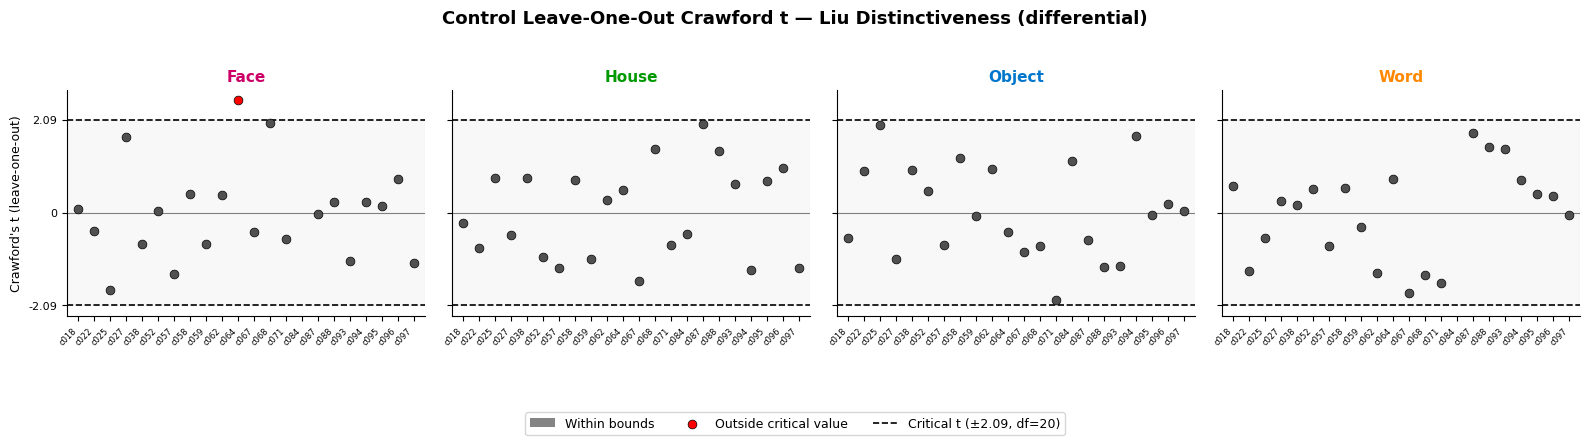

  Saved: fig_crawford_controls_differential.png


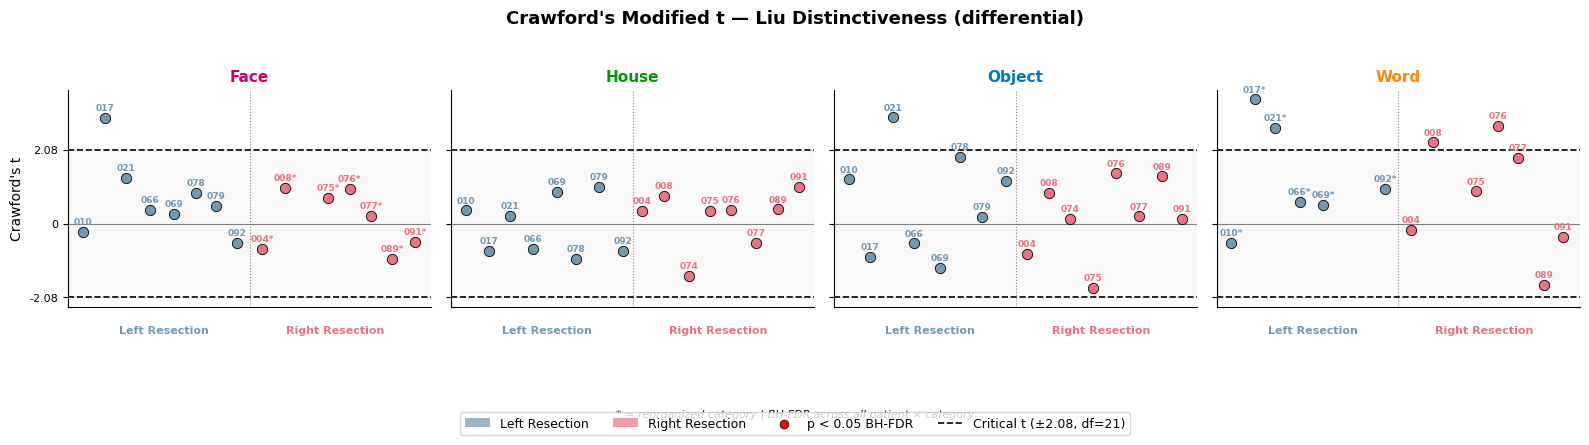

  Saved: fig_crawford_differential.png


In [7]:
# CELL 6: Crawford t-score figures — controls (LOO) and patients
# ═══════════════════════════════════════════════════════════════════════════════

def _compute_crawford_controls(ctrl):
    """Leave-one-out Crawford t for each control x category."""
    rows = []
    for cat in CATEGORIES:
        ref_hemi = PREFERRED_CTRL_HEMI[cat]
        cat_ctrl = ctrl[(ctrl['category'] == cat) &
                        (ctrl['hemi_label'] == ref_hemi)]
        all_vals = cat_ctrl['liu_distinctiveness'].values
        for _, row in cat_ctrl.iterrows():
            loo_vals = all_vals[all_vals != row['liu_distinctiveness']]
            t, p, _  = crawford_t(row['liu_distinctiveness'], loo_vals)
            rows.append({'subject': row['subject'], 'category': cat,
                         't': t, 'p': p})
    return pd.DataFrame(rows)


def fig_crawford_controls(cope_set=COPE_SET):
    """Leave-one-out Crawford t for each control, one panel per category."""
    ctrl, _ = load_liu_first_session(cope_set)
    if ctrl is None:
        return
    cdf    = _compute_crawford_controls(ctrl)
    n_ctrl = ctrl['subject_id'].nunique()
    t_crit = sp_stats.t.ppf(0.975, df=n_ctrl - 2)

    ctrl_subs = sorted(cdf['subject'].unique(), key=short_name)
    sub_x     = {s: i + 1 for i, s in enumerate(ctrl_subs)}
    n_cats    = len(CATEGORIES)

    fig, axes = plt.subplots(1, n_cats, figsize=(4 * n_cats, 4), sharey=True)

    for col_idx, cat in enumerate(CATEGORIES):
        ax      = axes[col_idx]
        cat_cdf = cdf[cdf['category'] == cat]
        ax.axhline(0,        color='gray',  linewidth=0.8, zorder=1)
        ax.axhline( t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhline(-t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhspan(-t_crit, t_crit, alpha=0.05, color='gray', zorder=0)

        for _, row in cat_cdf.iterrows():
            if np.isnan(row['t']):
                continue
            dot = 'red' if abs(row['t']) > t_crit else CTRL_R
            ax.scatter(sub_x[row['subject']], row['t'], color=dot,
                       s=40, zorder=4, edgecolors='black', linewidth=0.5)

        ax.set_xlim(0.3, len(ctrl_subs) + 0.7)
        ax.set_xticks(list(sub_x.values()))
        ax.set_xticklabels([short_name(s) for s in ctrl_subs],
                           fontsize=6, rotation=45, ha='right')
        ax.set_title(cat.title(), fontsize=11, fontweight='bold',
                     color=CAT_COLORS[cat])
        if col_idx == 0:
            ax.set_ylabel("Crawford's t (leave-one-out)", fontsize=9)
            ax.set_yticks([-t_crit, 0, t_crit])
            ax.set_yticklabels([f'{-t_crit:.2f}', '0', f'{t_crit:.2f}'], fontsize=8)

    fig.legend(handles=[
        Patch(facecolor=CTRL_R, alpha=0.7, label='Within bounds'),
        plt.scatter([], [], color='red', s=40, edgecolors='black',
                    linewidth=0.5, label='Outside critical value'),
        Line2D([0], [0], color='black', linewidth=1.2, linestyle='--',
               label=f'Critical t (\u00b1{t_crit:.2f}, df={n_ctrl-2})'),
    ], loc='lower center', ncol=3, fontsize=9, frameon=True,
       bbox_to_anchor=(0.5, -0.1))

    plt.suptitle(f'Control Leave-One-Out Crawford t \u2014 Liu Distinctiveness ({cope_set})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_crawford_controls_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_crawford_controls_{cope_set}.png')


def fig_crawford_distinctiveness(cope_set=COPE_SET):
    """Crawford t-scores for OTC patients, one panel per category."""
    ctrl, otc = load_liu_first_session(cope_set)
    if ctrl is None:
        return
    cdf    = compute_crawford_rows(ctrl, otc)
    n_ctrl = ctrl['subject_id'].nunique()
    t_crit = sp_stats.t.ppf(0.975, df=n_ctrl - 1)
    n_cats = len(CATEGORIES)

    left_pts  = sorted(cdf[cdf['surgery_side'] == 'left']['subject'].unique(),
                       key=short_name)
    right_pts = sorted(cdf[cdf['surgery_side'] == 'right']['subject'].unique(),
                       key=short_name)
    all_pts   = left_pts + right_pts
    pt_x      = {sub: i + 1 for i, sub in enumerate(all_pts)}
    divider_x = len(left_pts) + 0.5

    fig, axes = plt.subplots(1, n_cats, figsize=(4 * n_cats, 4), sharey=True)

    for col_idx, cat in enumerate(CATEGORIES):
        ax      = axes[col_idx]
        cat_cdf = cdf[cdf['category'] == cat]
        ax.axhline(0,        color='gray',  linewidth=0.8, zorder=1)
        ax.axhline( t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhline(-t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhspan(-t_crit, t_crit, alpha=0.05, color='gray', zorder=0)
        ax.axvline(divider_x, color='gray', linewidth=0.8, linestyle=':', zorder=1)

        for _, row in cat_cdf.iterrows():
            if np.isnan(row['t']):
                continue
            x    = pt_x[row['subject']] + RNG.uniform(-0.1, 0.1)
            base = OTC_L if row['surgery_side'] == 'left' else OTC_R
            dot  = 'red' if row['sig'] else base
            star = '*' if REORG.get(row['surgery_side']) == cat else ''
            ax.scatter(x, row['t'], color=dot, s=55, zorder=4,
                       edgecolors='black', linewidth=0.6)
            ax.annotate(f"{short_name(row['subject'])}{star}",
                        (x, row['t']), fontsize=6.5, fontweight='bold',
                        ha='center', va='bottom', xytext=(0, 4),
                        textcoords='offset points', color=dot)

        ax.set_xticks([])
        ax.set_xlim(0.3, len(all_pts) + 0.7)
        ax.set_title(cat.title(), fontsize=11, fontweight='bold',
                     color=CAT_COLORS[cat])
        if col_idx == 0:
            ax.set_ylabel("Crawford's t", fontsize=10)
            ax.set_yticks([-t_crit, 0, t_crit])
            ax.set_yticklabels([f'{-t_crit:.2f}', '0', f'{t_crit:.2f}'], fontsize=8)

        n_all = len(all_pts)
        ax.text((len(left_pts) / 2 + 0.5) / (n_all + 1), -0.12, 'Left Resection',
                ha='center', fontsize=8, color=OTC_L, fontweight='bold',
                transform=ax.transAxes, clip_on=False)
        ax.text((len(left_pts) + len(right_pts) / 2 + 0.5) / (n_all + 1), -0.12,
                'Right Resection', ha='center', fontsize=8, color=OTC_R,
                fontweight='bold', transform=ax.transAxes, clip_on=False)

    fig.legend(handles=[
        Patch(facecolor=OTC_L, alpha=0.7, label='Left Resection'),
        Patch(facecolor=OTC_R, alpha=0.7, label='Right Resection'),
        plt.scatter([], [], color='red', s=40, edgecolors='black',
                    linewidth=0.5, label='p < 0.05 BH-FDR'),
        Line2D([0], [0], color='black', linewidth=1.2, linestyle='--',
               label=f'Critical t (\u00b1{t_crit:.2f}, df={n_ctrl-1})'),
    ], loc='lower center', ncol=4, fontsize=9, frameon=True,
       bbox_to_anchor=(0.5, -0.1))
    fig.text(0.5, -0.04, '* = reorganized category | BH-FDR across all patient \u00d7 category',
             ha='center', fontsize=8, style='italic')

    plt.suptitle(f"Crawford's Modified t \u2014 Liu Distinctiveness ({cope_set})",
                 fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_crawford_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_crawford_{cope_set}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_crawford_controls(COPE_SET)
fig_crawford_distinctiveness(COPE_SET)

/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/home/csimmon2/anaconda3/envs/fmri/lib/python3.9/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(
/tmp/ipykernel_3903776/2249276736.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.ti

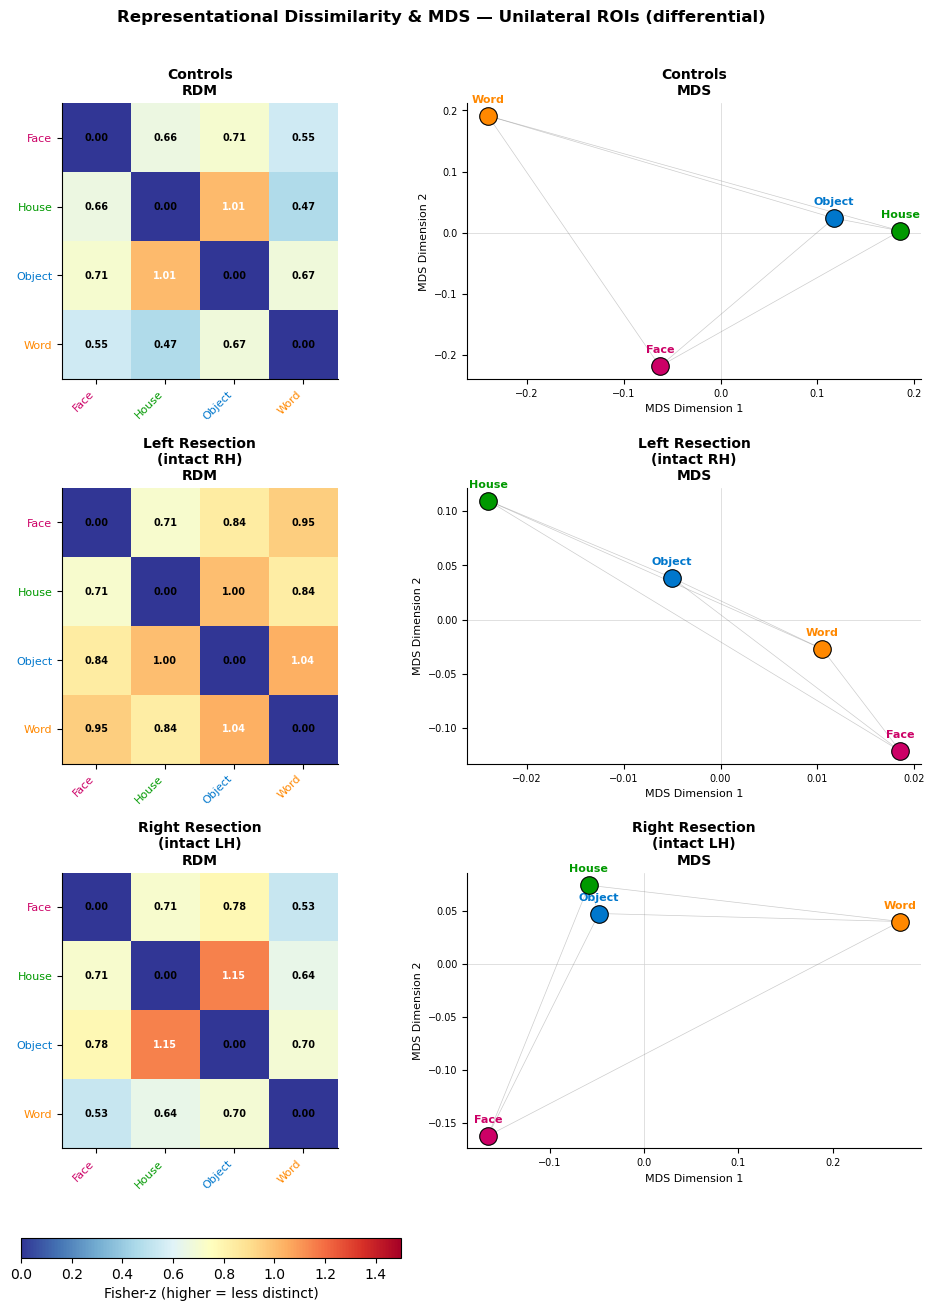

  Saved: fig_rdm_mds_unilateral_differential.png


In [8]:
# CELL 7: RDM + MDS figure
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.manifold import MDS


def fig_rdm_mds(cope_set=COPE_SET, roi_type='unilateral'):
    """3-row x 2-col figure: RDM (left) + MDS (right) per group.
    Rows: Controls | OTC Left Resection | OTC Right Resection."""

    pair_file = LIU_DIR / f'pairwise_correlations_{cope_set}.csv'
    if not pair_file.exists():
        print(f'  SKIP: {pair_file} not found')
        return

    df = pd.read_csv(pair_file)

    # First session per subject
    first = (df.groupby('subject_id')['session'].min()
               .reset_index().rename(columns={'session': 'fs'}))
    df = df.merge(first, on='subject_id')
    df = df[df['session'] == df['fs']]

    df['plot_group'] = df.apply(
        lambda r: f"OTC-{r['surgery_side']}" if r['group'] == 'OTC' else r['group'],
        axis=1)
    uni = df[df['cat_type'] == roi_type].copy()
    uni = uni[~((uni['group'] == 'OTC') & (uni['hemi_label'] != 'intact'))]

    cats  = CATEGORIES
    n_cat = len(cats)

    def get_mean_matrix(subset):
        """Build n x n mean Fisher-z matrix for a group subset."""
        mat = np.full((n_cat, n_cat), np.nan)
        for i, ci in enumerate(cats):
            for j, cj in enumerate(cats):
                if i == j:
                    mat[i, j] = 0.0
                    continue
                for pair_str in [f'{ci}-{cj}', f'{cj}-{ci}']:
                    v = subset[subset['pair'] == pair_str]['fisher_r'].values
                    if len(v) > 0:
                        mat[i, j] = v.mean()
                        break
        return mat

    groups = [
        ('control',   'Controls'),
        ('OTC-left',  'Left Resection\n(intact RH)'),
        ('OTC-right', 'Right Resection\n(intact LH)'),
    ]

    tick_labels = [c.title() for c in cats]

    fig, axes = plt.subplots(3, 2, figsize=(10 + (n_cat - 4), 13))
    fig.patch.set_facecolor('white')

    for row_idx, (grp, title) in enumerate(groups):
        ax_rdm = axes[row_idx, 0]
        ax_mds = axes[row_idx, 1]

        gd  = uni[uni['plot_group'] == grp]
        mat = get_mean_matrix(gd)

        # ── RDM ──────────────────────────────────────────────────────────────
        im = ax_rdm.imshow(mat, cmap='RdYlBu_r', vmin=0, vmax=1.5, aspect='equal')
        ax_rdm.set_xticks(range(n_cat))
        ax_rdm.set_xticklabels(tick_labels, fontsize=8, rotation=45, ha='right')
        ax_rdm.set_yticks(range(n_cat))
        ax_rdm.set_yticklabels(tick_labels, fontsize=8)
        ax_rdm.set_title(f'{title}\nRDM', fontsize=10, fontweight='bold')

        for i, cat in enumerate(cats):
            ax_rdm.get_xticklabels()[i].set_color(CAT_COLORS[cat])
            ax_rdm.get_yticklabels()[i].set_color(CAT_COLORS[cat])

        for i in range(n_cat):
            for j in range(n_cat):
                if np.isnan(mat[i, j]):
                    continue
                txt_col = 'white' if mat[i, j] > 1.0 else 'black'
                ax_rdm.text(j, i, f'{mat[i,j]:.2f}',
                            ha='center', va='center',
                            fontsize=7, color=txt_col, fontweight='bold')

        # ── MDS ──────────────────────────────────────────────────────────────
        sim = mat.copy()
        np.fill_diagonal(sim, 0)
        col_means = np.nanmean(sim, axis=0)
        for i in range(n_cat):
            for j in range(n_cat):
                if np.isnan(sim[i, j]):
                    sim[i, j] = (col_means[i] + col_means[j]) / 2
        dissim = np.clip(1 - sim, 0, None)
        dissim = (dissim + dissim.T) / 2
        np.fill_diagonal(dissim, 0)

        mds    = MDS(n_components=2, dissimilarity='precomputed',
                     random_state=42, n_init=10)
        coords = mds.fit_transform(dissim)

        for k, cat in enumerate(cats):
            color = CAT_COLORS[cat]
            ax_mds.scatter(coords[k, 0], coords[k, 1],
                           color=color, s=160, zorder=4,
                           edgecolors='black', linewidth=0.8)
            ax_mds.annotate(cat.title(),
                            (coords[k, 0], coords[k, 1]),
                            fontsize=8, fontweight='bold',
                            ha='center', va='bottom',
                            xytext=(0, 8), textcoords='offset points',
                            color=color)

        for i in range(n_cat):
            for j in range(i + 1, n_cat):
                ax_mds.plot([coords[i, 0], coords[j, 0]],
                            [coords[i, 1], coords[j, 1]],
                            color='gray', linewidth=0.5, alpha=0.4, zorder=2)

        ax_mds.set_title(f'{title}\nMDS', fontsize=10, fontweight='bold')
        ax_mds.set_xlabel('MDS Dimension 1', fontsize=8)
        ax_mds.set_ylabel('MDS Dimension 2', fontsize=8)
        ax_mds.tick_params(labelsize=7)
        ax_mds.spines[['top', 'right']].set_visible(False)
        ax_mds.axhline(0, color='lightgray', linewidth=0.5, zorder=1)
        ax_mds.axvline(0, color='lightgray', linewidth=0.5, zorder=1)

    cbar_ax = fig.add_axes([0.08, 0.02, 0.38, 0.015])
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal',
                 label='Fisher-z (higher = less distinct)')

    plt.suptitle(
        f'Representational Dissimilarity & MDS \u2014 {roi_type.title()} ROIs ({cope_set})',
        fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.06, 1, 0.97])
    plt.savefig(str(FIG_DIR / f'fig_rdm_mds_{roi_type}_{cope_set}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_rdm_mds_{roi_type}_{cope_set}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_rdm_mds(COPE_SET)

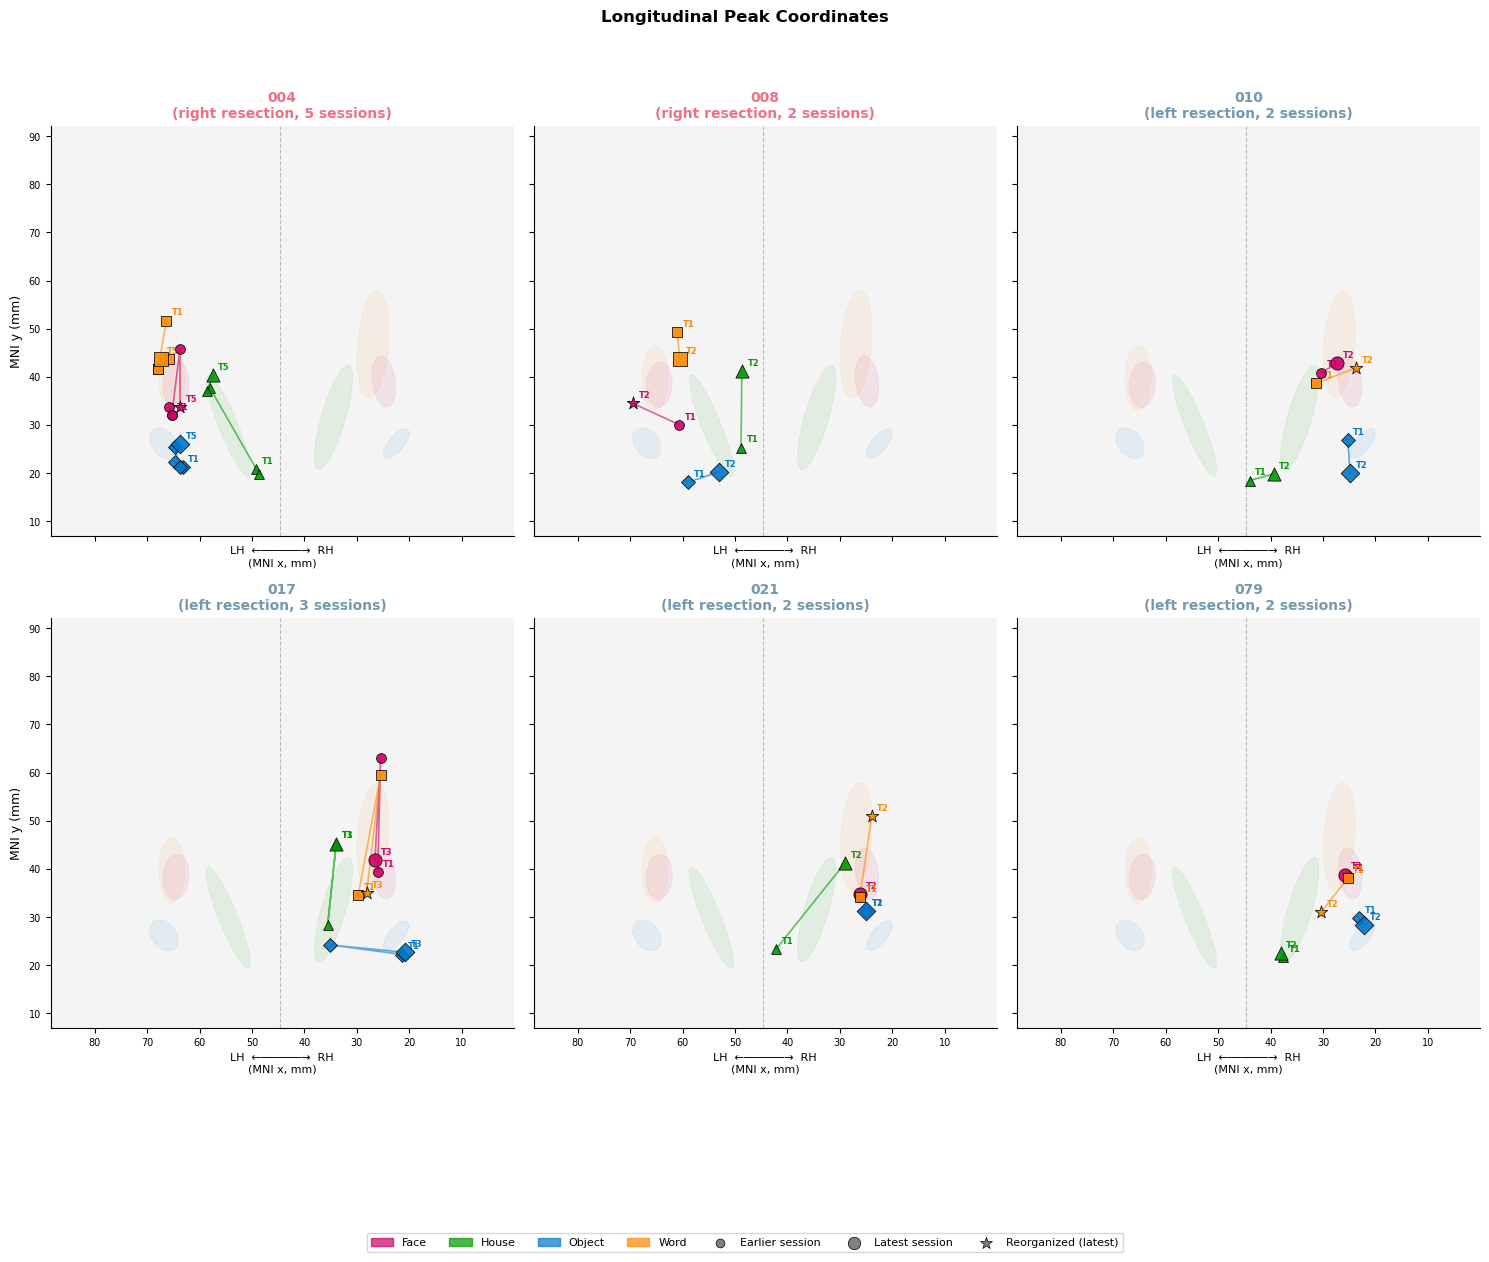

  Saved: fig_longitudinal_spatial.png


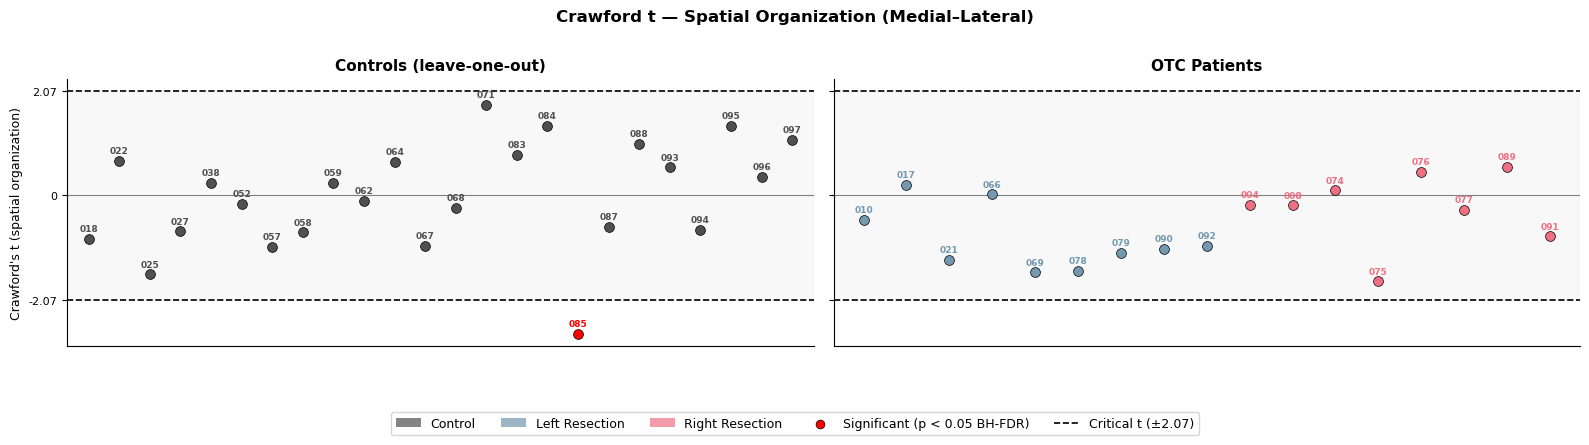

  Saved: fig_crawford_spatial.png


In [10]:

# CELL 8: Longitudinal Peak Coordinates + Crawford Spatial Organization
# ═══════════════════════════════════════════════════════════════════════════════

MIN_SESSIONS_LONG = 2


def fig_longitudinal_spatial(suffix=''):
    """One panel per longitudinal patient (>= 2 sessions): peak MNI coordinates
    per session, color-coded by category, connected across sessions."""

    pk_file = BASE / 'group_results' / 'peak_coords' / f'peak_coords{suffix}.csv'
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)

    otc = df[df['group'] == 'OTC'].copy()
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')
    otc = otc[((otc['intact_hemi'] == 'left')  & (otc['hemi'] == 'left')) |
              ((otc['intact_hemi'] == 'right') & (otc['hemi'] == 'right'))]

    n_ses    = otc.groupby('sub')['ses_int'].nunique()
    eligible = sorted(n_ses[n_ses >= MIN_SESSIONS_LONG].index.tolist())

    ctrl      = df[df['group'] == 'control'].copy()
    lx        = ctrl[ctrl['hemi'] == 'left']['peak_x_mni'].mean()
    rx        = ctrl[ctrl['hemi'] == 'right']['peak_x_mni'].mean()
    midline_x = (lx + rx) / 2

    pad  = 10
    xlim = (ctrl['peak_x_mni'].min() - pad, ctrl['peak_x_mni'].max() + pad)
    ylim = (ctrl['peak_y_mni'].min() - pad, ctrl['peak_y_mni'].max() + pad)

    n_pts = len(eligible)
    if n_pts == 0:
        print('  SKIP: no patients with >= 2 sessions')
        return
    n_cols = int(np.ceil(n_pts / 2))
    n_rows = min(2, n_pts)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 6 * n_rows),
                             sharey=True, sharex=True,
                             squeeze=False)
    fig.patch.set_facecolor('white')

    for idx, sub in enumerate(eligible):
        row_i = idx // n_cols
        col_i = idx % n_cols
        ax    = axes[row_i, col_i]
        ax.set_facecolor('#f4f4f4')
        sub_df = otc[otc['sub'] == sub].sort_values('ses_int')
        side   = sub_df['surgery_side'].iloc[0]
        col    = OTC_L if side == 'left' else OTC_R
        lbl    = short_name(sub)
        sessions = sorted(sub_df['ses_int'].unique())

        # Faint control ellipses as reference
        for cat in CATEGORIES:
            color = CAT_COLORS[cat]
            for hemi, ls in [('left', '--'), ('right', '-')]:
                hdat = ctrl[(ctrl['category'] == cat) &
                            (ctrl['hemi'] == hemi)].dropna(
                                subset=['peak_x_mni', 'peak_y_mni'])
                cx, cy = hdat['peak_x_mni'].values, hdat['peak_y_mni'].values
                if len(cx) >= 3:
                    confidence_ellipse(cx, cy, ax, n_std=1.0,
                                       facecolor=color, alpha=0.07,
                                       edgecolor=color, linewidth=0.8,
                                       linestyle=ls, zorder=1)

        # Per-category trajectories across sessions
        for cat in CATEGORIES:
            color  = CAT_COLORS[cat]
            cat_df = sub_df[sub_df['category'] == cat].sort_values('ses_int')
            xs     = cat_df['peak_x_mni'].values
            ys     = cat_df['peak_y_mni'].values
            ses_ids = cat_df['ses_int'].values

            if len(xs) < 1:
                continue
            if len(xs) > 1:
                ax.plot(xs, ys, color=color, linewidth=1.2, alpha=0.6, zorder=3)

            for i, (x, y, s) in enumerate(zip(xs, ys, ses_ids)):
                is_last = (i == len(xs) - 1)
                ax.scatter(x, y, color=color,
                           s=90 if is_last else 50,
                           marker='*' if (REORG.get(side) == cat and is_last)
                                      else CAT_MARKERS[cat],
                           edgecolors='black', linewidth=0.6,
                           alpha=0.9, zorder=4)
                if i == 0 or is_last:
                    ax.annotate(f'T{i+1}', (x, y), fontsize=6, color=color,
                                xytext=(4, 4), textcoords='offset points',
                                fontweight='bold')

        ax.axvline(midline_x, color='gray', linewidth=0.8,
                   linestyle='--', alpha=0.5)
        ax.set_xlim(xlim)
        ax.invert_xaxis()
        ax.set_ylim(ylim)
        ax.set_xlabel('LH  \u2190\u2500\u2500\u2500\u2500\u2500\u2500\u2192  RH\n(MNI x, mm)', fontsize=8)
        if col_i == 0:
            ax.set_ylabel('MNI y (mm)', fontsize=9)
        ax.set_title(f'{lbl}\n({side} resection, {len(sessions)} sessions)',
                     fontsize=10, fontweight='bold', color=col)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)

    # Hide empty axes if odd number of patients
    for idx in range(n_pts, n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    legend_cats  = [Patch(facecolor=CAT_COLORS[c], alpha=0.7,
                          edgecolor=CAT_COLORS[c],
                          label=c.title()) for c in CATEGORIES]
    legend_extra = [
        plt.scatter([], [], color='gray', marker='o', s=40,
                    edgecolors='black', linewidth=0.5, label='Earlier session'),
        plt.scatter([], [], color='gray', marker='o', s=80,
                    edgecolors='black', linewidth=0.5, label='Latest session'),
        plt.scatter([], [], color='gray', marker='*', s=80,
                    edgecolors='black', linewidth=0.5, label='Reorganized (latest)'),
    ]
    fig.legend(handles=legend_cats + legend_extra,
               loc='lower center', ncol=min(7, len(CATEGORIES) + 3),
               fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.06))

    suf_label = f' [{suffix[1:]}]' if suffix else ''
    plt.suptitle(f'Longitudinal Peak Coordinates{suf_label}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_longitudinal_spatial{suffix}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_longitudinal_spatial{suffix}.png')


def fig_crawford_spatial(suffix=''):
    """Crawford t-scores for spatial organization (medial-lateral x-coordinate
    correlation with control mean), controls (LOO) and patients."""

    pk_file = BASE / 'group_results' / 'peak_coords' / f'peak_coords{suffix}.csv'
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)
    first = (df.groupby('sub')['ses_int'].min()
               .reset_index().rename(columns={'ses_int': 'fs'}))
    df = df.merge(first, on='sub')
    df = df[df['ses_int'] == df['fs']]

    ctrl = df[df['group'] == 'control'].copy()
    otc  = df[df['group'] == 'OTC'].copy()
    otc  = otc[((otc['intact_hemi'] == 'left')  & (otc['hemi'] == 'left')) |
               ((otc['intact_hemi'] == 'right') & (otc['hemi'] == 'right'))]

    def spatial_corr(sub_df, ref_mean):
        sub_mean    = sub_df.groupby('category')['peak_x_mni'].mean()
        cats_shared = sorted(set(sub_mean.index) & set(ref_mean.index))
        if len(cats_shared) < 3:
            return np.nan
        r, _ = sp_stats.pearsonr(sub_mean.loc[cats_shared].values,
                                  ref_mean.loc[cats_shared].values)
        return float(r)

    ctrl_mean_x = ctrl.groupby('category')['peak_x_mni'].mean()

    def fz(r):
        return 0.5 * np.log((1 + np.clip(r, -0.999, 0.999)) /
                             (1 - np.clip(r, -0.999, 0.999)))

    # Controls: leave-one-out
    ctrl_subs  = sorted(ctrl['sub'].unique())
    ctrl_corrs = {}
    for sub in ctrl_subs:
        sub_df   = ctrl[ctrl['sub'] == sub]
        loo_mean = ctrl[ctrl['sub'] != sub].groupby('category')['peak_x_mni'].mean()
        r        = spatial_corr(sub_df, loo_mean)
        ctrl_corrs[sub] = fz(r) if not np.isnan(r) else np.nan

    ctrl_fz = np.array([v for v in ctrl_corrs.values() if not np.isnan(v)])
    n_ctrl  = len(ctrl_fz)
    t_crit  = sp_stats.t.ppf(0.975, df=n_ctrl - 2)

    ctrl_t = {}
    for sub in ctrl_subs:
        val = ctrl_corrs.get(sub, np.nan)
        if np.isnan(val):
            continue
        loo = np.array([v for s, v in ctrl_corrs.items()
                        if s != sub and not np.isnan(v)])
        t, _, _ = crawford_t(val, loo)
        ctrl_t[sub] = t

    # Patients
    otc['surgery_side'] = otc['intact_hemi'].map(
        lambda h: 'right' if h == 'left' else 'left')
    otc_subs  = sorted(otc['sub'].unique(),
                       key=lambda s: otc[otc['sub'] == s]['surgery_side'].iloc[0])
    otc_t, otc_sides = {}, {}
    for sub in otc_subs:
        sub_df = otc[otc['sub'] == sub]
        r      = spatial_corr(sub_df, ctrl_mean_x)
        fz_val = fz(r) if not np.isnan(r) else np.nan
        t, _, _ = (crawford_t(fz_val, ctrl_fz) if not np.isnan(fz_val)
                   else (np.nan, np.nan, 0))
        otc_t[sub]     = t
        otc_sides[sub] = sub_df['surgery_side'].iloc[0]

    pt_subs  = [s for s in otc_subs if not np.isnan(otc_t.get(s, np.nan))]
    pt_pvals = [2 * sp_stats.t.sf(abs(otc_t[s]), df=n_ctrl - 1) for s in pt_subs]
    pt_sig   = bh_fdr(np.array(pt_pvals)) if pt_pvals else []
    pt_sig_map = {s: sig for s, sig in zip(pt_subs, pt_sig)}

    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

    for ax, (subs, t_dict, title, is_ctrl_panel) in zip(axes, [
        (ctrl_subs, ctrl_t, 'Controls (leave-one-out)', True),
        (otc_subs,  otc_t,  'OTC Patients',             False),
    ]):
        ax.axhline(0,        color='gray',  linewidth=0.8, zorder=1)
        ax.axhline( t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhline(-t_crit,  color='black', linewidth=1.2, linestyle='--', zorder=2)
        ax.axhspan(-t_crit, t_crit, alpha=0.05, color='gray', zorder=0)

        for x_idx, sub in enumerate(subs):
            t = t_dict.get(sub, np.nan)
            if np.isnan(t):
                continue
            if is_ctrl_panel:
                col = CTRL_R
                dot = 'red' if abs(t) > t_crit else col
            else:
                side = otc_sides[sub]
                col  = OTC_L if side == 'left' else OTC_R
                dot  = 'red' if pt_sig_map.get(sub, False) else col

            ax.scatter(x_idx + 1, t, color=dot, s=50,
                       edgecolors='black', linewidth=0.5, zorder=4)
            ax.annotate(short_name(sub), (x_idx + 1, t),
                        fontsize=6.5, fontweight='bold',
                        ha='center', va='bottom', xytext=(0, 4),
                        textcoords='offset points', color=dot)

        ax.set_xlim(0.3, len(subs) + 0.7)
        ax.set_xticks([])
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)

    axes[0].set_ylabel("Crawford's t (spatial organization)", fontsize=9)
    axes[0].set_yticks([-t_crit, 0, t_crit])
    axes[0].set_yticklabels([f'{-t_crit:.2f}', '0', f'{t_crit:.2f}'], fontsize=8)

    fig.legend(handles=[
        Patch(facecolor=CTRL_R, alpha=0.7, label='Control'),
        Patch(facecolor=OTC_L,  alpha=0.7, label='Left Resection'),
        Patch(facecolor=OTC_R,  alpha=0.7, label='Right Resection'),
        plt.scatter([], [], color='red', s=40, edgecolors='black',
                    linewidth=0.5, label='Significant (p < 0.05 BH-FDR)'),
        Line2D([0], [0], color='black', linewidth=1.2, linestyle='--',
               label=f'Critical t (\u00b1{t_crit:.2f})'),
    ], loc='lower center', ncol=5, fontsize=9, frameon=True,
       bbox_to_anchor=(0.5, -0.1))

    plt.suptitle('Crawford t \u2014 Spatial Organization (Medial\u2013Lateral)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.1, 1, 0.97])
    plt.savefig(str(FIG_DIR / f'fig_crawford_spatial{suffix}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_crawford_spatial{suffix}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_longitudinal_spatial()
fig_crawford_spatial()

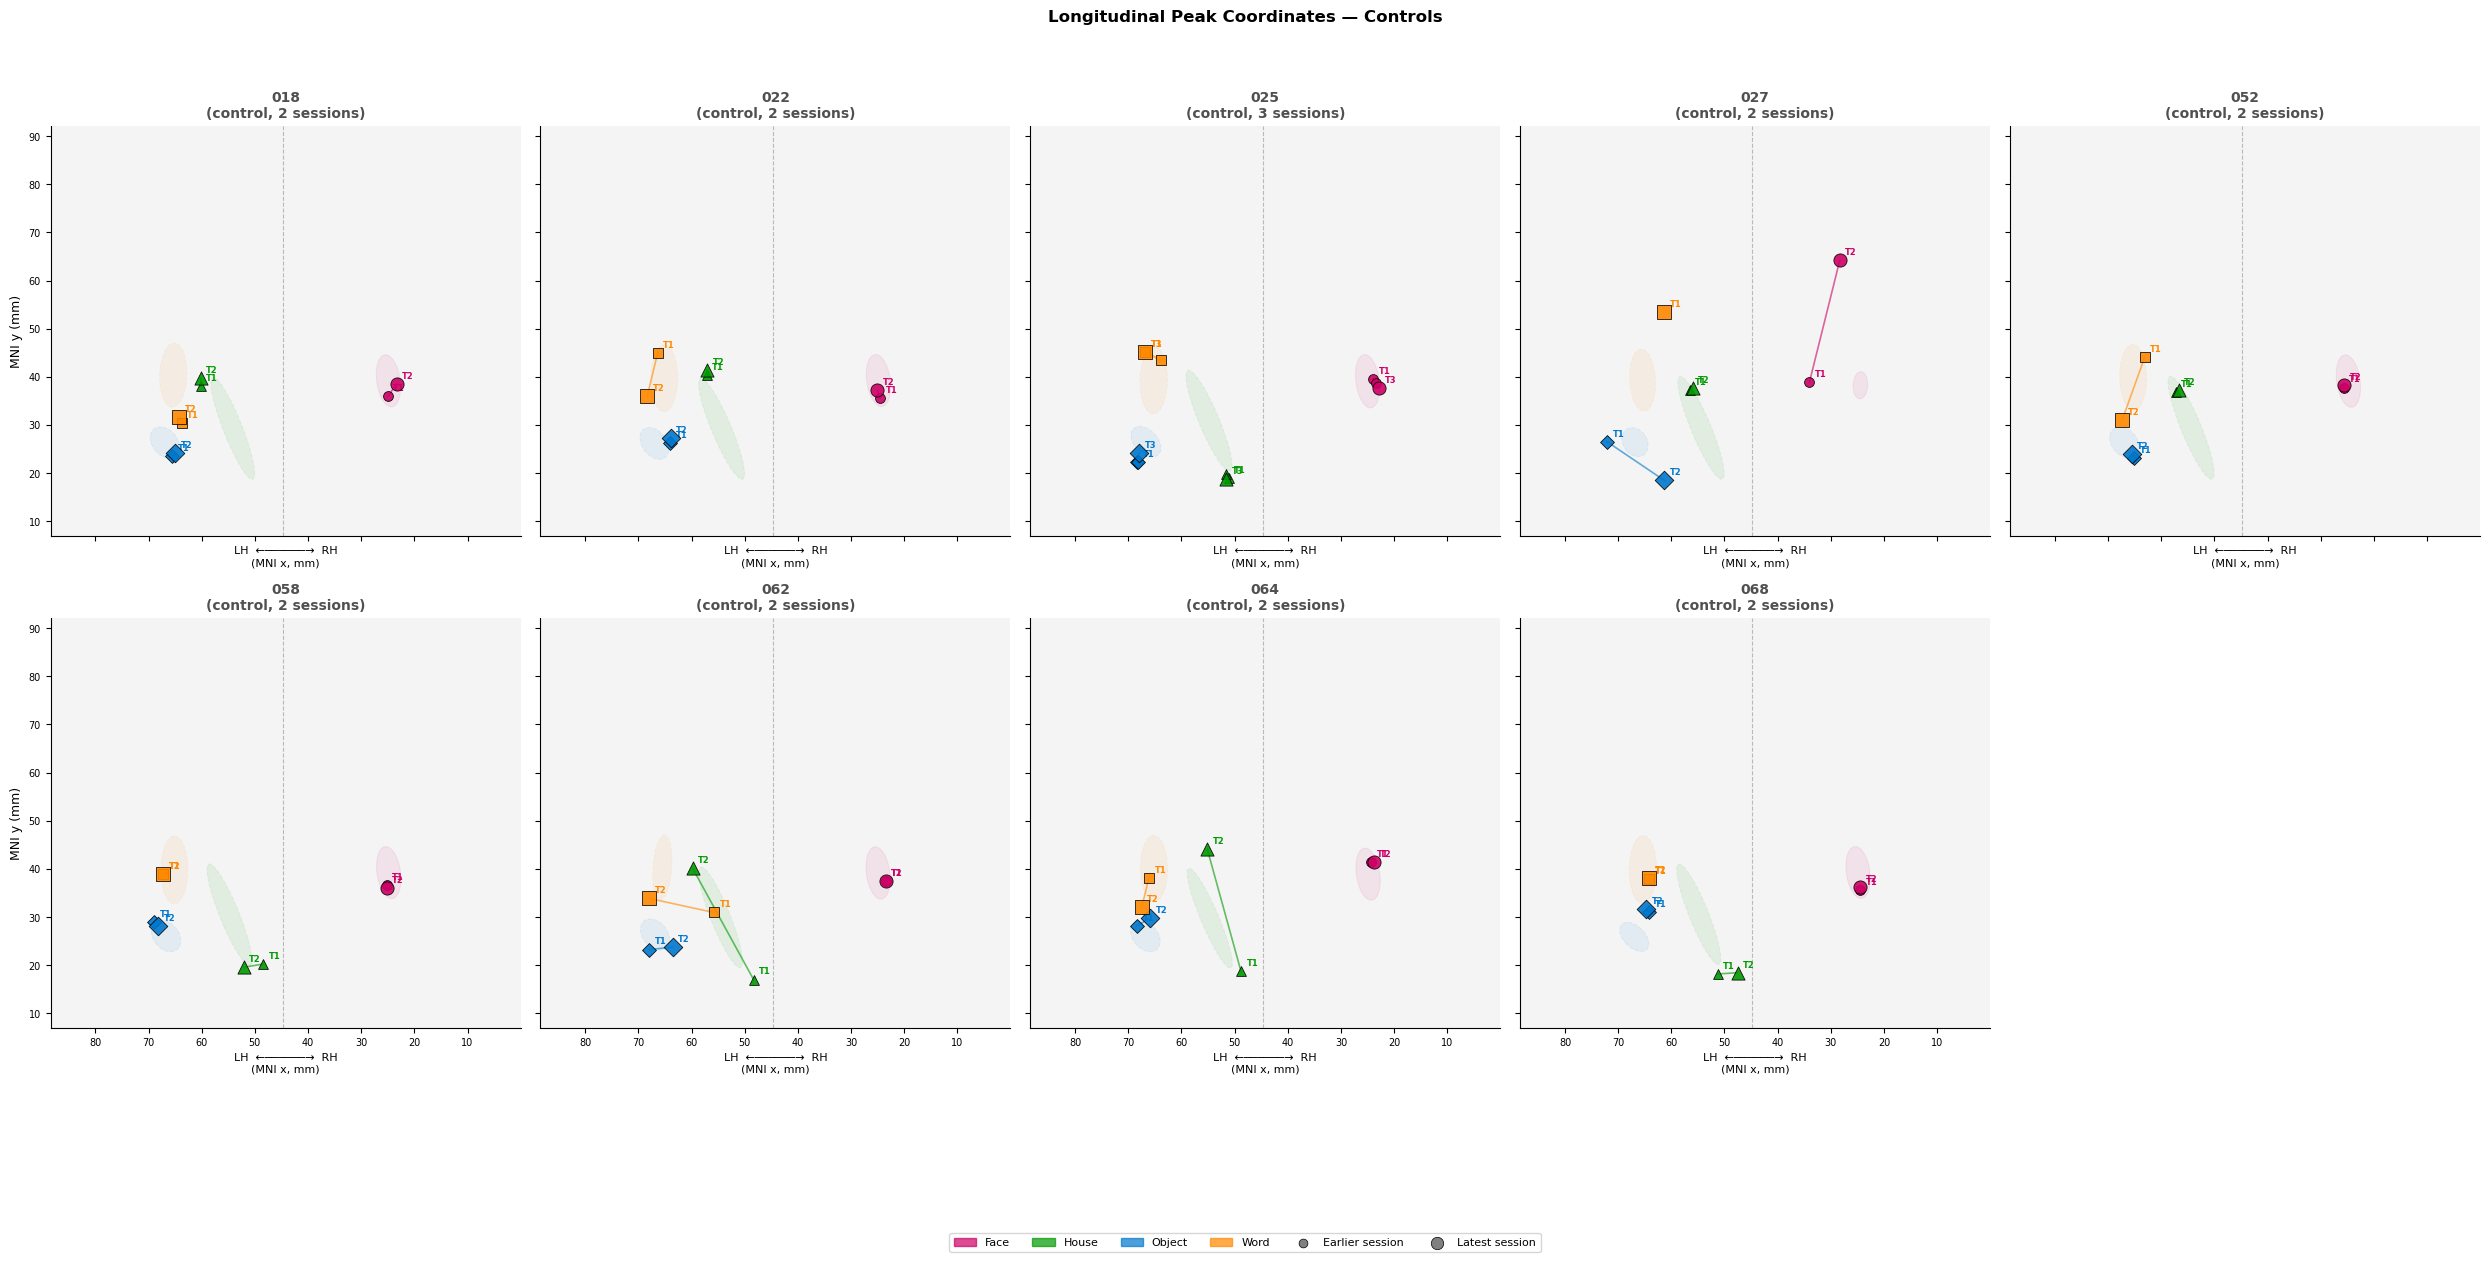

  Saved: fig_longitudinal_spatial_controls.png


In [13]:
# CELL 9: Longitudinal Peak Coordinates — Controls
# ═══════════════════════════════════════════════════════════════════════════════

def fig_longitudinal_spatial_controls(suffix=''):
    """One panel per longitudinal control (>= 2 sessions): peak MNI coordinates
    per session, color-coded by category, connected across sessions.
    Both hemispheres shown for each control."""

    pk_file = BASE / 'group_results' / 'peak_coords' / f'peak_coords{suffix}.csv'
    if not pk_file.exists():
        print(f'  SKIP: {pk_file} not found')
        return

    df = pd.read_csv(pk_file)
    df['ses_int'] = df['ses'].astype(int)

    ctrl = df[df['group'] == 'control'].copy()

    n_ses    = ctrl.groupby('sub')['ses_int'].nunique()
    eligible = sorted(n_ses[n_ses >= MIN_SESSIONS_LONG].index.tolist())

    if len(eligible) == 0:
        print('  SKIP: no controls with >= 2 sessions')
        return

    lx        = ctrl[ctrl['hemi'] == 'left']['peak_x_mni'].mean()
    rx        = ctrl[ctrl['hemi'] == 'right']['peak_x_mni'].mean()
    midline_x = (lx + rx) / 2

    pad  = 10
    xlim = (ctrl['peak_x_mni'].min() - pad, ctrl['peak_x_mni'].max() + pad)
    ylim = (ctrl['peak_y_mni'].min() - pad, ctrl['peak_y_mni'].max() + pad)

    n_pts = len(eligible)
    n_cols = int(np.ceil(n_pts / 2))
    n_rows = min(2, n_pts)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 6 * n_rows),
                             sharey=True, sharex=True,
                             squeeze=False)
    fig.patch.set_facecolor('white')

    for idx, sub in enumerate(eligible):
        row_i = idx // n_cols
        col_i = idx % n_cols
        ax    = axes[row_i, col_i]
        ax.set_facecolor('#f4f4f4')
        sub_df   = ctrl[ctrl['sub'] == sub].sort_values('ses_int')
        lbl      = short_name(sub)
        sessions = sorted(sub_df['ses_int'].unique())

        # Faint group ellipses as reference (preferred hemi only)
        for cat in CATEGORIES:
            color = CAT_COLORS[cat]
            pref  = PREFERRED_CTRL_HEMI[cat]
            ls    = '--' if pref == 'left' else '-'
            hdat  = ctrl[(ctrl['sub'] != sub) &
                         (ctrl['category'] == cat) &
                         (ctrl['hemi'] == pref)].dropna(
                             subset=['peak_x_mni', 'peak_y_mni'])
            cx, cy = hdat['peak_x_mni'].values, hdat['peak_y_mni'].values
            if len(cx) >= 3:
                confidence_ellipse(cx, cy, ax, n_std=1.0,
                                   facecolor=color, alpha=0.07,
                                   edgecolor=color, linewidth=0.8,
                                   linestyle=ls, zorder=1)

        # Per-category trajectories across sessions (preferred hemi only)
        for cat in CATEGORIES:
            color    = CAT_COLORS[cat]
            pref     = PREFERRED_CTRL_HEMI[cat]
            cat_df   = sub_df[(sub_df['category'] == cat) &
                              (sub_df['hemi'] == pref)].sort_values('ses_int')
            xs      = cat_df['peak_x_mni'].values
            ys      = cat_df['peak_y_mni'].values
            ses_ids = cat_df['ses_int'].values

            if len(xs) < 1:
                continue
            if len(xs) > 1:
                ax.plot(xs, ys, color=color, linewidth=1.2, alpha=0.6, zorder=3)

            for i, (x, y, s) in enumerate(zip(xs, ys, ses_ids)):
                is_last = (i == len(xs) - 1)
                ax.scatter(x, y, color=color,
                           s=90 if is_last else 50,
                           marker=CAT_MARKERS[cat],
                           edgecolors='black', linewidth=0.6,
                           alpha=0.9, zorder=4)
                if i == 0 or is_last:
                    ax.annotate(f'T{i+1}', (x, y), fontsize=6, color=color,
                                xytext=(4, 4), textcoords='offset points',
                                fontweight='bold')

        ax.axvline(midline_x, color='gray', linewidth=0.8,
                   linestyle='--', alpha=0.5)
        ax.set_xlim(xlim)
        ax.invert_xaxis()
        ax.set_ylim(ylim)
        ax.set_xlabel('LH  \u2190\u2500\u2500\u2500\u2500\u2500\u2500\u2192  RH\n(MNI x, mm)', fontsize=8)
        if col_i == 0:
            ax.set_ylabel('MNI y (mm)', fontsize=9)
        ax.set_title(f'{lbl}\n(control, {len(sessions)} sessions)',
                     fontsize=10, fontweight='bold', color=CTRL_R)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)

    # Hide empty axes
    for idx in range(n_pts, n_rows * n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    legend_cats  = [Patch(facecolor=CAT_COLORS[c], alpha=0.7,
                          edgecolor=CAT_COLORS[c],
                          label=c.title()) for c in CATEGORIES]
    legend_extra = [
        plt.scatter([], [], color='gray', marker='o', s=40,
                    edgecolors='black', linewidth=0.5, label='Earlier session'),
        plt.scatter([], [], color='gray', marker='o', s=80,
                    edgecolors='black', linewidth=0.5, label='Latest session'),
    ]
    fig.legend(handles=legend_cats + legend_extra,
               loc='lower center', ncol=min(6, len(CATEGORIES) + 2),
               fontsize=8, frameon=True, bbox_to_anchor=(0.5, -0.06))

    suf_label = f' [{suffix[1:]}]' if suffix else ''
    plt.suptitle(f'Longitudinal Peak Coordinates \u2014 Controls{suf_label}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.savefig(str(FIG_DIR / f'fig_longitudinal_spatial_controls{suffix}.png'),
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'  Saved: fig_longitudinal_spatial_controls{suffix}.png')


# ── Run ───────────────────────────────────────────────────────────────────────
fig_longitudinal_spatial_controls()